In [1]:
from geotracks import SEVIRIDataBuffer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

# SEVIRI data field
- already been regridded onto regular grid

In [2]:
# open seviri data field
data_field=xr.open_dataset('/disk1/Users/act122/shiptracks/test_field.nc').cdnc.load()/1e6

# open example ship track
track=xr.open_dataset('/disk1/Users/act122/shiptracks/tracklocs/SEVIRI/namibia_tracklocs_2018003.nc').isel(time=15,id=9)
track = np.stack([track['lon'].values, track['lat'].values, track['alt'].values], axis=-1)

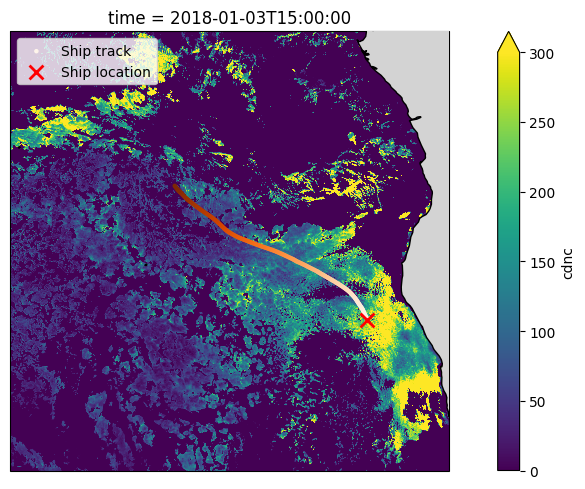

In [ ]:
# plot
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
data_field.plot(x='Longitude', y='Latitude', cmap='viridis', vmax=300,transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=10,facecolor='lightgray',edgecolor='black')
ax.scatter(track[:, 0], track[:, 1], c=np.linspace(0, 1, len(track)), cmap='Oranges', s=5, transform=ccrs.PlateCarree(),label='Ship track')
ax.scatter(track[0, 0], track[0, 1], c='red', s=100,lw=2,marker='x', transform=ccrs.PlateCarree(),label='Ship location')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Regrid around the track

In [25]:
buf = SEVIRIDataBuffer(track,factor=10)
df1 = buf.extract(data_field)
# buf = SEVIRIDataBuffer(track,factor=20)
# df2 = buf.extract(data_field)


216


# put into 2D plot (depending on desired resolution)

In [26]:
DIST_BINS = np.arange(-100, 101, 1)
TIME_BINS = np.arange(0, 37, 0.5)


df1["dist_binned"] = pd.cut(
    df1["distance_from_track"], DIST_BINS, labels=DIST_BINS[:-1]
)
df1["time_binned"] = pd.cut(df1["time_along_track"], TIME_BINS, labels=TIME_BINS[:-1])

df12d = pd.pivot_table(
    df1,
    index="dist_binned",
    columns="time_binned",
    values="data",
    aggfunc="mean",
    dropna=False,
)
ds2d_1 = xr.DataArray(df12d).isel(dist_binned=slice(1, 201))
ds2d_1=ds2d_1.to_dataset(name='cdnc')
ds2d_1['counts']=pd.pivot_table(
    df1,
    index="dist_binned",
    columns="time_binned",
    values="data",
    aggfunc="count",
    dropna=False,
)

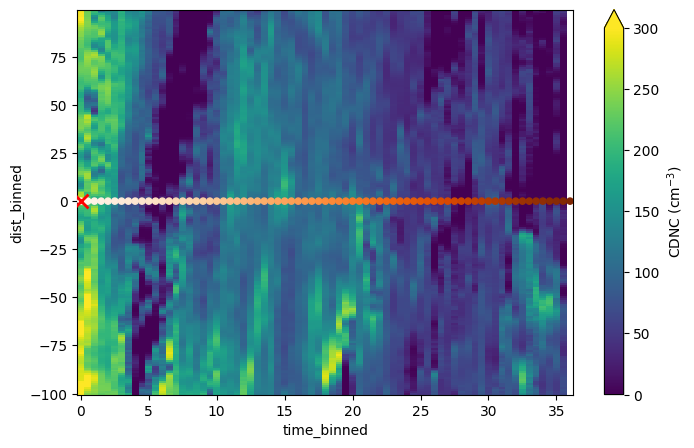

In [27]:
fig,ax=plt.subplots(figsize=(8, 5))
ds2d_1.cdnc.plot(vmax=300, ax=ax, cmap='viridis', cbar_kwargs={'label': 'CDNC (cm$^{-3}$)'})
zeroline= 0 * ds2d_1.cdnc.sel(dist_binned=0)
zeroline=zeroline.to_dataframe('zero').reset_index()[['time_binned','dist_binned']]
lplot=zeroline.plot.scatter(x='time_binned', y='dist_binned', c=np.linspace(0, 1, len(zeroline)),zorder=10,ax=ax,cmap='Oranges',colorbar=False)
ax.scatter(0,0, c='red', s=100, lw=2, marker='x',zorder=20)
# ax.scatter(0, color=np.linspace(0,1,37),cmap=,'Reds', lw=1, ls='--')
plt.show()

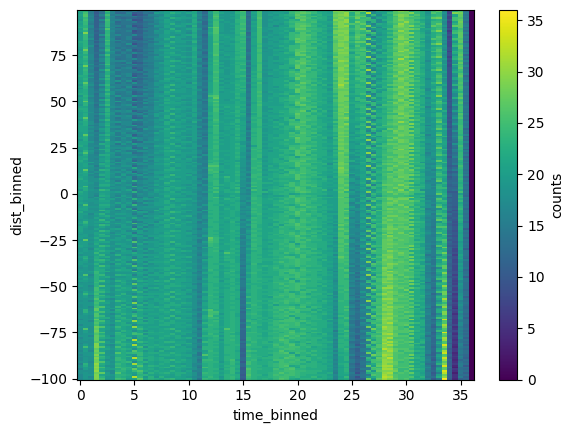

In [28]:
ds2d_1.counts.plot()
plt.show()